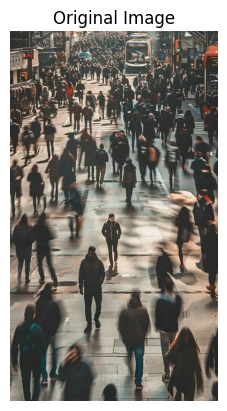

Running Semantic Segmentation...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:01<00:00, 145MB/s]


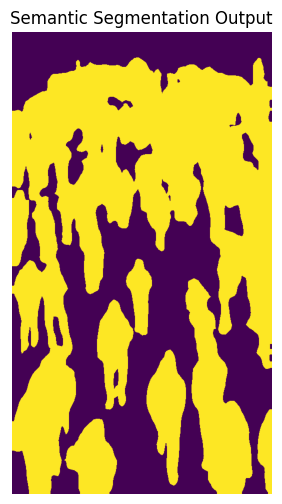

Running Instance Segmentation...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 151MB/s]


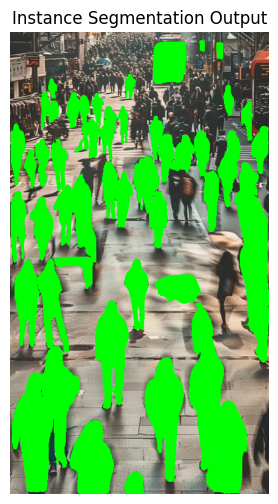

In [1]:
!pip install torch torchvision matplotlib pillow opencv-python

import torch
import torchvision.transforms as T
import torchvision.models as models
import torchvision.models.detection as detection
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2


image_path = "/content/street.webp"
image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()


print("Running Semantic Segmentation...")

semantic_model = models.segmentation.deeplabv3_resnet101(pretrained=True)
semantic_model.eval()

transform = T.Compose([
    T.Resize(520),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406],
                std=[0.229,0.224,0.225])
])

input_tensor = transform(image).unsqueeze(0)

with torch.no_grad():
    semantic_output = semantic_model(input_tensor)['out'][0]

semantic_mask = semantic_output.argmax(0).byte().cpu().numpy()

plt.figure(figsize=(8,6))
plt.imshow(semantic_mask)
plt.title("Semantic Segmentation Output")
plt.axis("off")
plt.show()



print("Running Instance Segmentation...")

instance_model = detection.maskrcnn_resnet50_fpn(pretrained=True)
instance_model.eval()

transform = T.ToTensor()
img_tensor = transform(image)

with torch.no_grad():
    predictions = instance_model([img_tensor])


image_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

for i in range(len(predictions[0]['masks'])):

    score = predictions[0]['scores'][i]

    if score > 0.5:

        mask = predictions[0]['masks'][i,0].mul(255).byte().cpu().numpy()

        image_cv[mask > 127] = [0,255,0]


plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB))
plt.title("Instance Segmentation Output")
plt.axis("off")
plt.show()